# Experiment 15: Class Imbalance vs Per-Identity AP Correlation

**Research Question:** Does per-identity AP correlate with the number of training images
per identity, or does visual distinctiveness matter more than data quantity?

## Overview

1. **Data Loading** — Stratified train/val split (seed=42, identical to all prior experiments)
2. **Backbone Loading** — DINOv2-ViT-L/14 (frozen), extract and cache embeddings
3. **Train ArcFace Head** — Best config from Experiment 13 (margin=0.6, scale=48,
   emb_dim=512, hidden=1024, dropout=0.3), 50 epochs
4. **Per-Identity AP** — Compute AP for each of the 31 identities on the val set
5. **Training Count Lookup** — Cross-reference with `train.csv` image counts per identity
6. **Spearman Correlation** — Statistical test: does more data → higher AP?
7. **Outlier Analysis** — Identify identities with high AP despite few images (visually
   distinctive) and low AP despite many images (visually ambiguous)
8. **Visualisation** — Scatter plot, sorted AP bar chart, sample images from outlier identities

## Hypothesis

Spearman ρ will be positive but moderate (0.3–0.6), meaning data quantity partially
explains performance but visual distinctiveness is a confounding factor. Some identities
with ≤15 training images will outperform identities with 80+ images.

## 1. Setup and Imports

In [1]:
import os, math, random, time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
from torchvision import transforms
from PIL import Image
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import wandb
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
os.environ["HF_TOKEN"]      = user_secrets.get_secret("hf_api")
os.environ["WANDB_API_KEY"] = user_secrets.get_secret("wandb_api")

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

RANDOM_SEED = 42
set_seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device:  {device}")
print(f"PyTorch: {torch.__version__}  |  timm: {timm.__version__}")


Device:  cuda
PyTorch: 2.9.0+cu126  |  timm: 1.0.24


## 2. Configuration

In [2]:
# Best config
config = {
    # Paths
    "data_dir":       Path("/kaggle/input/competitions/jaguar-re-id"),
    "checkpoint_dir": Path("/kaggle/working/checkpoints"),
    "cache_dir":      Path("/kaggle/working/embeddings"),

    # Backbone — DINOv2-ViT-L/14 (frozen)
    "backbone_model_id": "vit_large_patch14_dinov2.lvd142m",
    "backbone_name":     "DINOv2-ViT-L/14",
    "input_size":        518,
    "backbone_dim":      1024,

    # ArcFace head
    "arcface_margin": 0.6,
    "arcface_scale":  48.0,
    "embedding_dim":  512,
    "hidden_dim":     1024,
    "dropout":        0.3,

    # Training
    "learning_rate":      1e-4,
    "weight_decay":       1e-4,
    "num_epochs":         50,
    "batch_size":         32,
    "val_split":          0.2,
    "seed":               RANDOM_SEED,
    "scheduler_factor":   0.5,
    "scheduler_patience": 5,
}

config["checkpoint_dir"].mkdir(parents=True, exist_ok=True)
config["cache_dir"].mkdir(parents=True, exist_ok=True)

print("Experiment 15 Configuration:")
print(f"  Backbone:   {config['backbone_name']} (frozen)")
print(f"  margin:     {config['arcface_margin']}  scale: {config['arcface_scale']}")
print(f"  emb_dim:    {config['embedding_dim']}  hidden: {config['hidden_dim']}")
print(f"  dropout:    {config['dropout']}")
print(f"  Epochs:     {config['num_epochs']}  LR: {config['learning_rate']}")
print(f"  Val split:  {config['val_split']} (seed={config['seed']})")


Experiment 15 Configuration:
  Backbone:   DINOv2-ViT-L/14 (frozen)
  margin:     0.6  scale: 48.0
  emb_dim:    512  hidden: 1024
  dropout:    0.3
  Epochs:     50  LR: 0.0001
  Val split:  0.2 (seed=42)


## 3. W&B Initialisation

In [3]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: pranav-birari (pranav-birari-university-of-potsdam) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
wandb.init(
    project=os.getenv("WANDB_PROJECT", "jaguar-reid-iota"),
    name="class-imbalance-ap-correlation",
    config={
        "experiment":       "class-imbalance-ap-correlation",
        "backbone":         config["backbone_name"],
        "arcface_margin":   config["arcface_margin"],
        "arcface_scale":    config["arcface_scale"],
        "embedding_dim":    config["embedding_dim"],
        "hidden_dim":       config["hidden_dim"],
        "dropout":          config["dropout"],
        "learning_rate":    config["learning_rate"],
        "weight_decay":     config["weight_decay"],
        "num_epochs":       config["num_epochs"],
        "batch_size":       config["batch_size"],
        "val_split":        config["val_split"],
        "seed":             config["seed"],
    }
)
print("W&B run initialised: class-imbalance-ap-correlation")
print("  Training metrics  → train/")
print("  Per-identity AP   → per_identity/")
print("  Correlation stats → correlation/")


W&B run initialised: class-imbalance-ap-correlation
  Training metrics  → train/
  Per-identity AP   → per_identity/
  Correlation stats → correlation/


## 4. Load Data and Stratified Split

In [5]:
train_df = pd.read_csv(config["data_dir"] / "train.csv")

print(f"Training dataset:")
print(f"  Total images:      {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")

identity_counts = train_df["ground_truth"].value_counts()
print(f"\nIdentity distribution:")
print(f"  Min:  {identity_counts.min()} ({identity_counts.idxmin()})")
print(f"  Max:  {identity_counts.max()} ({identity_counts.idxmax()})")
print(f"  Mean: {identity_counts.mean():.1f}")


Training dataset:
  Total images:      1895
  Unique identities: 31

Identity distribution:
  Min:  13 (Ipepo)
  Max:  183 (Marcela)
  Mean: 61.1


In [6]:
label_encoder = LabelEncoder()
train_df["label_encoded"] = label_encoder.fit_transform(train_df["ground_truth"])
num_classes = len(label_encoder.classes_)

# Identical stratified split to all prior experiments
train_data, val_data = train_test_split(
    train_df,
    test_size    = config["val_split"],
    random_state = config["seed"],
    stratify     = train_df["ground_truth"],
)

train_identities = set(train_data["ground_truth"].unique())
val_identities   = set(val_data["ground_truth"].unique())
assert train_identities == val_identities, "Identity leak!"

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images  ({100*(1-config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images  ({100*config['val_split']:.0f}%)")
print(f"  Identities in both sets: {len(train_identities & val_identities)}/{num_classes} ✓")

# Training image count per identity — KEY variable for the correlation analysis
train_counts_per_id = train_data["ground_truth"].value_counts().to_dict()

val_labels  = val_data["ground_truth"].values
train_image_paths = [config["data_dir"] / "train" / "train" / fn
                     for fn in train_data["filename"].astype(str)]
val_image_paths   = [config["data_dir"] / "train" / "train" / fn
                     for fn in val_data["filename"].astype(str)]

wandb.log({
    "num_identities":  num_classes,
    "train_samples":   len(train_data),
    "val_samples":     len(val_data),
})
print(f"\nTraining counts per identity (range): "
      f"{min(train_counts_per_id.values())} – {max(train_counts_per_id.values())}")


Dataset split:
  Training:   1516 images  (80%)
  Validation: 379 images  (20%)
  Identities in both sets: 31/31 ✓

Training counts per identity (range): 10 – 147


## 5. Load DINOv2 Backbone and Extract Embeddings

DINOv2-ViT-L/14 is loaded once, frozen, and used to extract embeddings for train and val sets.
Embeddings are cached to disk so they can be reused if the session restarts.


In [7]:
transform = transforms.Compose([
    transforms.Resize((config["input_size"], config["input_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

@torch.no_grad()
def extract_embeddings(backbone, image_paths, desc="Extracting", batch_size=32):
    backbone.eval()
    all_embs = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc=desc):
        batch_paths = image_paths[i:i + batch_size]
        tensors = []
        for p in batch_paths:
            try:
                img = Image.open(p).convert("RGB")
            except Exception as e:
                print(f"  [WARN] {p}: {e}")
                img = Image.new("RGB", (config["input_size"], config["input_size"]))
            tensors.append(transform(img))
        batch = torch.stack(tensors).to(device)
        all_embs.append(backbone(batch).cpu().numpy())
    return np.vstack(all_embs)

# Cache paths
train_cache = config["cache_dir"] / "dinov2_train_embeddings.npz"
val_cache   = config["cache_dir"] / "dinov2_val_embeddings.npz"

if train_cache.exists() and val_cache.exists():
    print("Loading cached DINOv2 embeddings...")
    train_embeddings = np.load(train_cache)["embeddings"]
    val_embeddings   = np.load(val_cache)["embeddings"]
    print(f"  Train: {train_embeddings.shape}  |  Val: {val_embeddings.shape}")
    backbone_dim = train_embeddings.shape[1]
else:
    print(f"Loading {config['backbone_name']}...")
    backbone = timm.create_model(
        config["backbone_model_id"],
        pretrained  = True,
        num_classes = 0,
        img_size    = config["input_size"],
    )
    backbone.eval()
    for p in backbone.parameters():
        p.requires_grad = False
    backbone.to(device)

    with torch.no_grad():
        dummy       = torch.randn(1, 3, config["input_size"], config["input_size"]).to(device)
        backbone_dim = backbone(dummy).shape[1]
    assert backbone_dim == config["backbone_dim"],         f"Dim mismatch: {backbone_dim} vs {config['backbone_dim']}"
    print(f"  Output dim: {backbone_dim} | Params: {sum(p.numel() for p in backbone.parameters()):,} | Frozen: True")

    train_embeddings = extract_embeddings(backbone, train_image_paths, "DINOv2 train")
    val_embeddings   = extract_embeddings(backbone, val_image_paths,   "DINOv2 val")

    np.savez_compressed(train_cache, embeddings=train_embeddings)
    np.savez_compressed(val_cache,   embeddings=val_embeddings)
    print(f"  Train: {train_embeddings.shape}  |  Val: {val_embeddings.shape}")
    print("  Embeddings cached ✓")

    del backbone
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

backbone_dim = train_embeddings.shape[1]
print(f"\nBackbone dim: {backbone_dim}")


Loading DINOv2-ViT-L/14...


model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

  Output dim: 1024 | Params: 304,367,616 | Frozen: True


DINOv2 train:   0%|          | 0/48 [00:00<?, ?it/s]

DINOv2 val:   0%|          | 0/12 [00:00<?, ?it/s]

  Train: (1516, 1024)  |  Val: (379, 1024)
  Embeddings cached ✓

Backbone dim: 1024


## 6. Model Architecture

In [8]:
class EmbeddingProjection(nn.Module):
    """Linear → BN → ReLU → Dropout → Linear → BN. Identical to all prior experiments."""
    def __init__(self, input_dim, hidden_dim=1024, output_dim=512, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.BatchNorm1d(output_dim),
        )
    def forward(self, x): return self.net(x)


class ArcFaceLayer(nn.Module):
    def __init__(self, embedding_dim, num_classes, margin=0.6, scale=48.0):
        super().__init__()
        self.scale = scale
        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)
        self.th    = math.cos(math.pi - margin)
        self.mm    = math.sin(math.pi - margin) * margin
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, emb, labels):
        emb_n = F.normalize(emb, p=2, dim=1)
        w_n   = F.normalize(self.weight, p=2, dim=1)
        cos   = torch.clamp(F.linear(emb_n, w_n), -1.0, 1.0)
        sin   = torch.sqrt(1.0 - cos ** 2)
        phi   = cos * self.cos_m - sin * self.sin_m
        phi   = torch.where(cos > self.th, phi, cos - self.mm)
        oh    = torch.zeros_like(cos).scatter_(1, labels.view(-1, 1).long(), 1.0)
        return (oh * phi + (1 - oh) * cos) * self.scale


class ArcFaceModel(nn.Module):
    def __init__(self, input_dim, num_classes,
                 embedding_dim=512, hidden_dim=1024,
                 margin=0.6, scale=48.0, dropout=0.3):
        super().__init__()
        self.projection = EmbeddingProjection(input_dim, hidden_dim, embedding_dim, dropout)
        self.arcface    = ArcFaceLayer(embedding_dim, num_classes, margin, scale)

    def forward(self, x, labels):
        emb    = self.projection(x)
        logits = self.arcface(emb, labels)
        return logits, emb

    def get_embeddings(self, x):
        return F.normalize(self.projection(x), p=2, dim=1)


print("Model architecture defined.")
print(f"  Projection: Linear({backbone_dim} → {config['hidden_dim']} → {config['embedding_dim']})")
print(f"  ArcFace:    margin={config['arcface_margin']}, scale={config['arcface_scale']}")


Model architecture defined.
  Projection: Linear(1024 → 1024 → 512)
  ArcFace:    margin=0.6, scale=48.0


## 7. Dataset and Training Utilities

In [9]:
class EmbeddingDataset(Dataset):
    def __init__(self, embeddings, labels):
        self.embeddings = torch.FloatTensor(embeddings)
        self.labels     = torch.LongTensor(labels)
    def __len__(self):        return len(self.labels)
    def __getitem__(self, i): return self.embeddings[i], self.labels[i]


def compute_val_map_overall(model, val_embs_np, val_labels_str):
    """Identity-balanced mAP (same function as all prior experiments)."""
    model.eval()
    with torch.no_grad():
        t    = torch.FloatTensor(val_embs_np).to(device)
        embs = model.get_embeddings(t).cpu().numpy()
    sim = embs @ embs.T
    np.fill_diagonal(sim, -1)
    id_aps = defaultdict(list)
    for q in range(len(val_labels_str)):
        ql       = val_labels_str[q]
        is_match = (val_labels_str == ql).astype(int); is_match[q] = 0
        n_pos    = is_match.sum()
        if n_pos == 0: continue
        order = np.argsort(-sim[q]); sm = is_match[order]
        cum   = np.cumsum(sm)
        prec  = cum / np.arange(1, len(sm) + 1)
        id_aps[ql].append(float(np.sum(prec * sm) / n_pos))
    return float(np.mean([np.mean(v) for v in id_aps.values()]))


def compute_per_identity_ap(model, val_embs_np, val_labels_str):
    """Returns {identity: mean_AP} dict for all 31 identities."""
    model.eval()
    with torch.no_grad():
        t    = torch.FloatTensor(val_embs_np).to(device)
        embs = model.get_embeddings(t).cpu().numpy()
    sim = embs @ embs.T
    np.fill_diagonal(sim, -1)
    id_aps = defaultdict(list)
    for q in range(len(val_labels_str)):
        ql       = val_labels_str[q]
        is_match = (val_labels_str == ql).astype(int); is_match[q] = 0
        n_pos    = is_match.sum()
        if n_pos == 0: continue
        order = np.argsort(-sim[q]); sm = is_match[order]
        cum   = np.cumsum(sm)
        prec  = cum / np.arange(1, len(sm) + 1)
        id_aps[ql].append(float(np.sum(prec * sm) / n_pos))
    return {k: float(np.mean(v)) for k, v in id_aps.items()}


print("Dataset and evaluation utilities defined ✓")


Dataset and evaluation utilities defined ✓


## 8. Train ArcFace Head

In [10]:
set_seed(config["seed"])

model = ArcFaceModel(
    input_dim     = backbone_dim,
    num_classes   = num_classes,
    embedding_dim = config["embedding_dim"],
    hidden_dim    = config["hidden_dim"],
    margin        = config["arcface_margin"],
    scale         = config["arcface_scale"],
    dropout       = config["dropout"],
).to(device)

train_ds = EmbeddingDataset(train_embeddings, train_data["label_encoded"].values)
val_ds   = EmbeddingDataset(val_embeddings,   val_data["label_encoded"].values)

train_loader = DataLoader(train_ds, batch_size=config["batch_size"],
                          shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=config["batch_size"],
                          shuffle=False, num_workers=0)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(),
                               lr=config["learning_rate"],
                               weight_decay=config["weight_decay"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min",
    factor=config["scheduler_factor"],
    patience=config["scheduler_patience"],
)

best_map      = 0.0
best_val_loss = float("inf")
best_epoch    = 0
ckpt_path     = config["checkpoint_dir"] / "exp15_dinov2_arcface_best.pth"
history       = {"train_loss": [], "val_loss": [], "val_map": [], "lr": []}
t0            = time.time()

print(f"Training DINOv2 + ArcFace ({config['num_epochs']} epochs)...")
print(f"  Config: margin={config['arcface_margin']}, scale={config['arcface_scale']}, "
      f"emb_dim={config['embedding_dim']}, hidden={config['hidden_dim']}")
print()

for epoch in range(config["num_epochs"]):
    # Train
    model.train()
    tr_loss = 0.0
    for embs, labs in train_loader:
        embs, labs = embs.to(device), labs.to(device)
        logits, _  = model(embs, labs)
        loss       = criterion(logits, labs)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        tr_loss   += loss.item()
    tr_loss /= len(train_loader)

    # Validate
    model.eval()
    vl_loss = 0.0
    with torch.no_grad():
        for embs, labs in val_loader:
            embs, labs = embs.to(device), labs.to(device)
            logits, _  = model(embs, labs)
            vl_loss   += criterion(logits, labs).item()
    vl_loss /= len(val_loader)

    val_map = compute_val_map_overall(model, val_embeddings, val_labels)

    scheduler.step(vl_loss)
    lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["val_map"].append(val_map)
    history["lr"].append(lr)

    wandb.log({
        "train/epoch":     epoch + 1,
        "train/tr_loss":   tr_loss,
        "train/vl_loss":   vl_loss,
        "train/val_map":   val_map,
        "train/lr":        lr,
    })

    if val_map > best_map:
        best_map      = val_map
        best_val_loss = vl_loss
        best_epoch    = epoch + 1
        torch.save({
            "epoch":            epoch + 1,
            "model_state_dict": model.state_dict(),
            "val_map":          val_map,
            "val_loss":         vl_loss,
            "backbone_dim":     backbone_dim,
            "num_classes":      num_classes,
            "config":           config,
        }, str(ckpt_path))

    if (epoch + 1) % 5 == 0:
        elapsed = time.time() - t0
        print(f"  ep {epoch+1:2d}/{config['num_epochs']} | "
              f"tr={tr_loss:.4f}  vl={vl_loss:.4f}  "
              f"mAP={val_map:.4f}  (best={best_map:.4f}) | "
              f"{elapsed/60:.1f}min")

print(f"\nTraining complete.")
print(f"  Best val mAP: {best_map:.4f}  at epoch {best_epoch}")
wandb.log({"train/best_val_map": best_map, "train/best_epoch": best_epoch})


Training DINOv2 + ArcFace (50 epochs)...
  Config: margin=0.6, scale=48.0, emb_dim=512, hidden=1024

  ep  5/50 | tr=5.5287  vl=5.1128  mAP=0.7482  (best=0.7482) | 0.0min
  ep 10/50 | tr=1.8882  vl=3.2694  mAP=0.8208  (best=0.8208) | 0.1min
  ep 15/50 | tr=0.7976  vl=2.7097  mAP=0.8512  (best=0.8512) | 0.1min
  ep 20/50 | tr=0.3083  vl=2.4523  mAP=0.8596  (best=0.8652) | 0.1min
  ep 25/50 | tr=0.1142  vl=2.3439  mAP=0.8623  (best=0.8652) | 0.1min
  ep 30/50 | tr=0.0990  vl=2.4235  mAP=0.8664  (best=0.8676) | 0.1min
  ep 35/50 | tr=0.0650  vl=2.3241  mAP=0.8674  (best=0.8676) | 0.2min
  ep 40/50 | tr=0.0330  vl=2.2265  mAP=0.8649  (best=0.8676) | 0.2min
  ep 45/50 | tr=0.0516  vl=2.2342  mAP=0.8630  (best=0.8676) | 0.2min
  ep 50/50 | tr=0.0211  vl=2.2272  mAP=0.8645  (best=0.8676) | 0.2min

Training complete.
  Best val mAP: 0.8676  at epoch 27


## 9. Training Curves

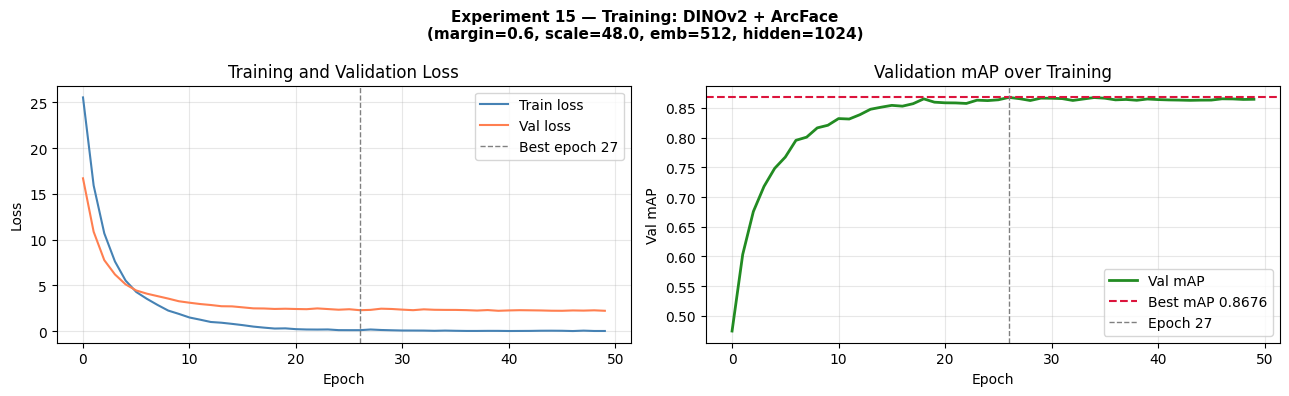

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(history["train_loss"], label="Train loss", color="steelblue")
ax.plot(history["val_loss"],   label="Val loss",   color="coral")
ax.axvline(x=best_epoch - 1, color="gray", linestyle="--", linewidth=1,
           label=f"Best epoch {best_epoch}")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Training and Validation Loss")
ax.legend(); ax.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(history["val_map"], color="forestgreen", linewidth=2, label="Val mAP")
ax2.axhline(y=best_map, color="crimson", linestyle="--",
            label=f"Best mAP {best_map:.4f}")
ax2.axvline(x=best_epoch - 1, color="gray", linestyle="--",
            linewidth=1, label=f"Epoch {best_epoch}")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Val mAP")
ax2.set_title("Validation mAP over Training")
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle(f"Experiment 15 — Training: DINOv2 + ArcFace\n"
             f"(margin={config['arcface_margin']}, scale={config['arcface_scale']}, "
             f"emb={config['embedding_dim']}, hidden={config['hidden_dim']})",
             fontsize=11, fontweight="bold")
plt.tight_layout()
wandb.log({"train/curves": wandb.Image(fig)})
plt.savefig(config["checkpoint_dir"] / "exp15_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Reload Best Checkpoint and Compute Per-Identity AP

We reload the best checkpoint and compute per-identity AP on the validation set.
This is the core metric that will be correlated with training image counts.


In [12]:
# Reload best checkpoint
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Reloaded best checkpoint: epoch={ckpt['epoch']}, val_mAP={ckpt['val_map']:.4f}")

# Compute per-identity AP for all 31 identities
per_id_ap = compute_per_identity_ap(model, val_embeddings, val_labels)

print(f"\nPer-identity AP computed for {len(per_id_ap)} identities")
print(f"  Mean AP:  {np.mean(list(per_id_ap.values())):.4f}")
print(f"  Min AP:   {min(per_id_ap.values()):.4f}  ({min(per_id_ap, key=per_id_ap.get)})")
print(f"  Max AP:   {max(per_id_ap.values()):.4f}  ({max(per_id_ap, key=per_id_ap.get)})")

# Build analysis dataframe
analysis_df = pd.DataFrame([
    {
        "identity":    ident,
        "ap":          per_id_ap[ident],
        "train_count": train_counts_per_id.get(ident, 0),
        "val_count":   int((val_labels == ident).sum()),
    }
    for ident in sorted(per_id_ap.keys())
])
analysis_df = analysis_df.sort_values("ap", ascending=False).reset_index(drop=True)

print("\nTop 5 by AP:")
print(analysis_df.head(5)[["identity","ap","train_count"]].to_string(index=False))
print("\nBottom 5 by AP:")
print(analysis_df.tail(5)[["identity","ap","train_count"]].to_string(index=False))


Reloaded best checkpoint: epoch=27, val_mAP=0.8676

Per-identity AP computed for 31 identities
  Mean AP:  0.8676
  Min AP:   0.0922  (Ipepo)
  Max AP:   1.0000  (Overa)

Top 5 by AP:
identity  ap  train_count
   Abril 1.0           17
  Akaloi 1.0           15
   Alira 1.0           18
    Jaju 1.0           83
Kamaikua 1.0           84

Bottom 5 by AP:
 identity       ap  train_count
 Patricia 0.642663           15
   Bororo 0.587910           18
  Bernard 0.342856           10
Pollyanna 0.341805           13
    Ipepo 0.092235           10


## 11. Spearman Rank Correlation

In [13]:
counts = analysis_df["train_count"].values
aps    = analysis_df["ap"].values

rho, pval = spearmanr(counts, aps)

print("=" * 55)
print("SPEARMAN CORRELATION: Training Count vs Per-Identity AP")
print("=" * 55)
print(f"  Spearman ρ:  {rho:+.4f}")
print(f"  p-value:     {pval:.4f}")
print(f"  n:           {len(analysis_df)} identities")
print()

if pval < 0.05:
    strength = "strong" if abs(rho) > 0.6 else ("moderate" if abs(rho) > 0.3 else "weak")
    direction = "positive" if rho > 0 else "negative"
    print(f"  Result: Statistically significant {strength} {direction} correlation (p<0.05)")
    if rho > 0:
        print(f"  More training images → higher AP (data quantity matters)")
    else:
        print(f"  Unexpected: more images → lower AP (possible noise)")
else:
    print(f"  Result: No statistically significant correlation (p={pval:.3f} ≥ 0.05)")
    print(f"  Visual distinctiveness, not data quantity, drives per-identity AP")

print("=" * 55)

wandb.log({
    "correlation/spearman_rho":  rho,
    "correlation/p_value":       pval,
    "correlation/significant":   pval < 0.05,
    "correlation/n_identities":  len(analysis_df),
})


SPEARMAN CORRELATION: Training Count vs Per-Identity AP
  Spearman ρ:  +0.2828
  p-value:     0.1232
  n:           31 identities

  Result: No statistically significant correlation (p=0.123 ≥ 0.05)
  Visual distinctiveness, not data quantity, drives per-identity AP


## 12. Outlier Analysis

We identify four quadrants based on median splits of training count and AP:

| Quadrant | Training count | AP | Interpretation |
|----------|---------------|-----|----------------|
| **Efficient** | Low | High | Visually distinctive — model learns from few examples |
| **Data-hungry** | High | High | Good performance, expected with more data |
| **Ambiguous** | High | Low | Visually ambiguous — more data didn't help |
| **Difficult** | Low | Low | Visually ambiguous AND data-scarce |


In [14]:
median_count = np.median(analysis_df["train_count"])
median_ap    = np.median(analysis_df["ap"])

def classify_quadrant(row):
    if row["train_count"] <= median_count and row["ap"] >= median_ap:
        return "Efficient (low data, high AP)"
    elif row["train_count"] > median_count and row["ap"] >= median_ap:
        return "Data-hungry (high data, high AP)"
    elif row["train_count"] > median_count and row["ap"] < median_ap:
        return "Ambiguous (high data, low AP)"
    else:
        return "Difficult (low data, low AP)"

analysis_df["quadrant"] = analysis_df.apply(classify_quadrant, axis=1)

print(f"Median training count: {median_count:.0f}")
print(f"Median AP:             {median_ap:.4f}")
print()
print("Quadrant counts:")
print(analysis_df["quadrant"].value_counts().to_string())
print()

# Identify top outliers in each key quadrant
efficient  = analysis_df[analysis_df["quadrant"] == "Efficient (low data, high AP)"].nlargest(3, "ap")
ambiguous  = analysis_df[analysis_df["quadrant"] == "Ambiguous (high data, low AP)"].nsmallest(3, "ap")

print("TOP 3 Efficient identities (low training count, high AP):")
print(efficient[["identity","ap","train_count","val_count"]].to_string(index=False))
print()
print("TOP 3 Ambiguous identities (high training count, low AP):")
print(ambiguous[["identity","ap","train_count","val_count"]].to_string(index=False))

wandb.log({
    "correlation/median_train_count": median_count,
    "correlation/median_ap":          median_ap,
    "correlation/n_efficient":  int((analysis_df["quadrant"] == "Efficient (low data, high AP)").sum()),
    "correlation/n_ambiguous":  int((analysis_df["quadrant"] == "Ambiguous (high data, low AP)").sum()),
    "correlation/n_data_hungry":int((analysis_df["quadrant"] == "Data-hungry (high data, high AP)").sum()),
    "correlation/n_difficult":  int((analysis_df["quadrant"] == "Difficult (low data, low AP)").sum()),
})


Median training count: 36
Median AP:             0.9926

Quadrant counts:
quadrant
Data-hungry (high data, high AP)    10
Difficult (low data, low AP)        10
Efficient (low data, high AP)        6
Ambiguous (high data, low AP)        5

TOP 3 Efficient identities (low training count, high AP):
identity  ap  train_count  val_count
   Abril 1.0           17          4
  Akaloi 1.0           15          4
   Alira 1.0           18          5

TOP 3 Ambiguous identities (high training count, low AP):
identity       ap  train_count  val_count
  Pixana 0.693414           40         10
 Marcela 0.945315          147         36
  Ousado 0.950296          143         36


## 13. Scatter Plot: Training Count vs Per-Identity AP

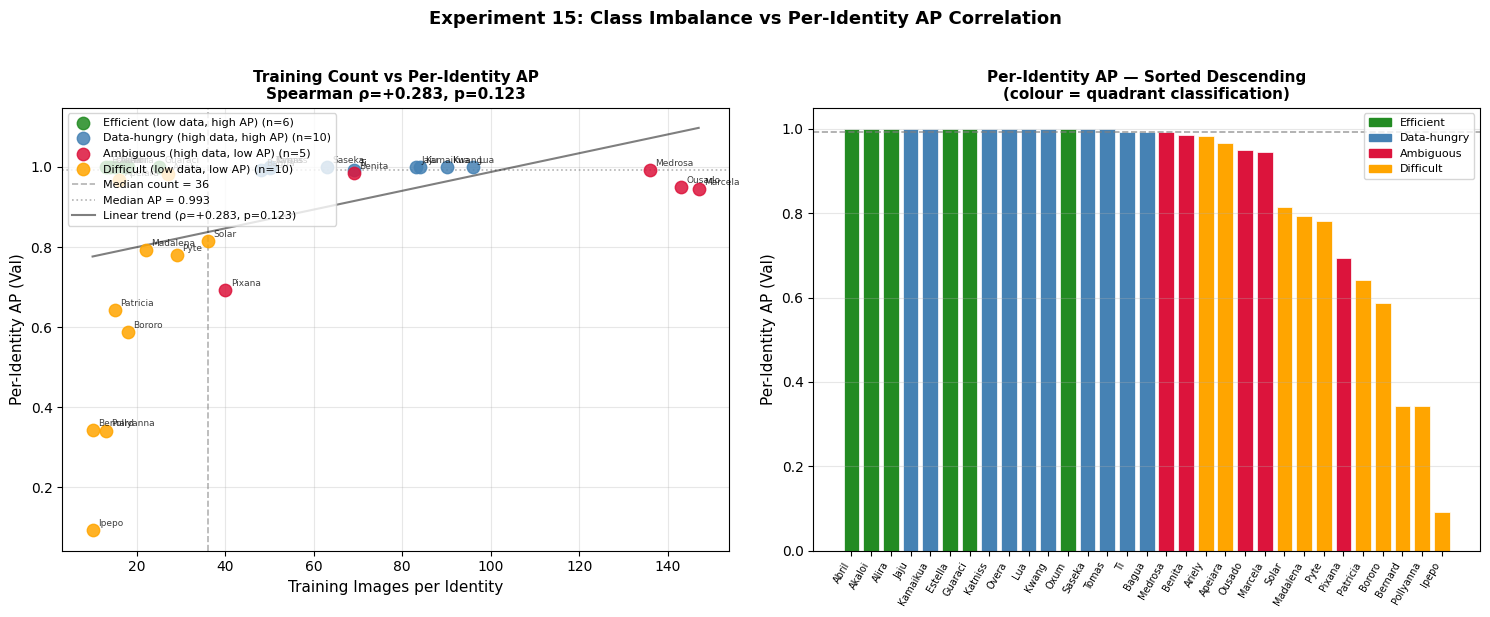

In [15]:
quadrant_colors = {
    "Efficient (low data, high AP)":    "forestgreen",
    "Data-hungry (high data, high AP)": "steelblue",
    "Ambiguous (high data, low AP)":    "crimson",
    "Difficult (low data, low AP)":     "orange",
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: scatter with quadrants
ax = axes[0]
for quadrant, color in quadrant_colors.items():
    subset = analysis_df[analysis_df["quadrant"] == quadrant]
    ax.scatter(subset["train_count"], subset["ap"],
               c=color, s=80, alpha=0.85,
               label=f"{quadrant} (n={len(subset)})", zorder=3)

# Label all identities
for _, row in analysis_df.iterrows():
    ax.annotate(row["identity"],
                (row["train_count"], row["ap"]),
                fontsize=6.5, alpha=0.75,
                xytext=(4, 3), textcoords="offset points")

# Median lines
ax.axvline(x=median_count, color="gray", linestyle="--", linewidth=1.2, alpha=0.6,
           label=f"Median count = {median_count:.0f}")
ax.axhline(y=median_ap,    color="gray", linestyle=":",  linewidth=1.2, alpha=0.6,
           label=f"Median AP = {median_ap:.3f}")

# Trend line
z = np.polyfit(analysis_df["train_count"], analysis_df["ap"], 1)
x_line = np.linspace(analysis_df["train_count"].min(),
                     analysis_df["train_count"].max(), 100)
ax.plot(x_line, np.polyval(z, x_line),
        color="black", linestyle="-", linewidth=1.5, alpha=0.5,
        label=f"Linear trend (ρ={rho:+.3f}, p={pval:.3f})")

ax.set_xlabel("Training Images per Identity", fontsize=11)
ax.set_ylabel("Per-Identity AP (Val)", fontsize=11)
ax.set_title("Training Count vs Per-Identity AP\n"
             f"Spearman ρ={rho:+.3f}, p={pval:.3f}",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.3)

# Right: AP bar chart sorted descending, coloured by quadrant
ax2 = axes[1]
sorted_df = analysis_df.sort_values("ap", ascending=False)
bar_colors = [quadrant_colors[q] for q in sorted_df["quadrant"]]

bars = ax2.bar(range(len(sorted_df)), sorted_df["ap"],
               color=bar_colors, edgecolor="white", linewidth=0.5)

ax2.axhline(y=median_ap, color="gray", linestyle="--", linewidth=1.2, alpha=0.7,
            label=f"Median AP = {median_ap:.3f}")
ax2.set_xticks(range(len(sorted_df)))
ax2.set_xticklabels(sorted_df["identity"], rotation=60, ha="right", fontsize=7)
ax2.set_ylabel("Per-Identity AP (Val)", fontsize=11)
ax2.set_title("Per-Identity AP — Sorted Descending\n"
              "(colour = quadrant classification)", fontsize=11, fontweight="bold")

patches = [mpatches.Patch(color=c, label=q.split("(")[0].strip())
           for q, c in quadrant_colors.items()]
ax2.legend(handles=patches, fontsize=8)
ax2.grid(axis="y", alpha=0.3)

plt.suptitle("Experiment 15: Class Imbalance vs Per-Identity AP Correlation",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
wandb.log({"correlation/scatter_and_bar": wandb.Image(fig)})
plt.savefig(config["checkpoint_dir"] / "exp15_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

## 14. Sample Images from Outlier Identities

We show 3 val images each for:
- The top-2 **Efficient** identities (high AP despite few training images)
- The top-2 **Ambiguous** identities (low AP despite many training images)

This lets us visually verify whether distinctiveness / ambiguity explains the outliers.


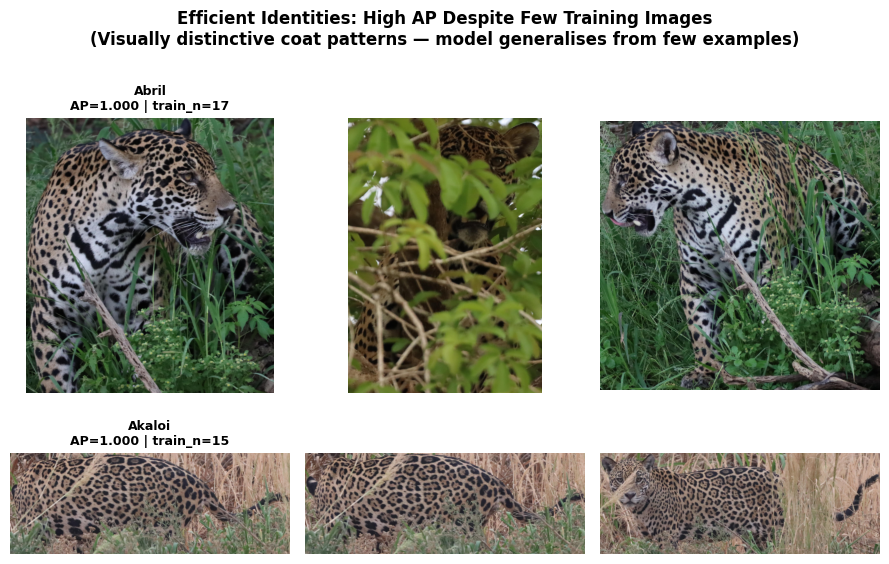

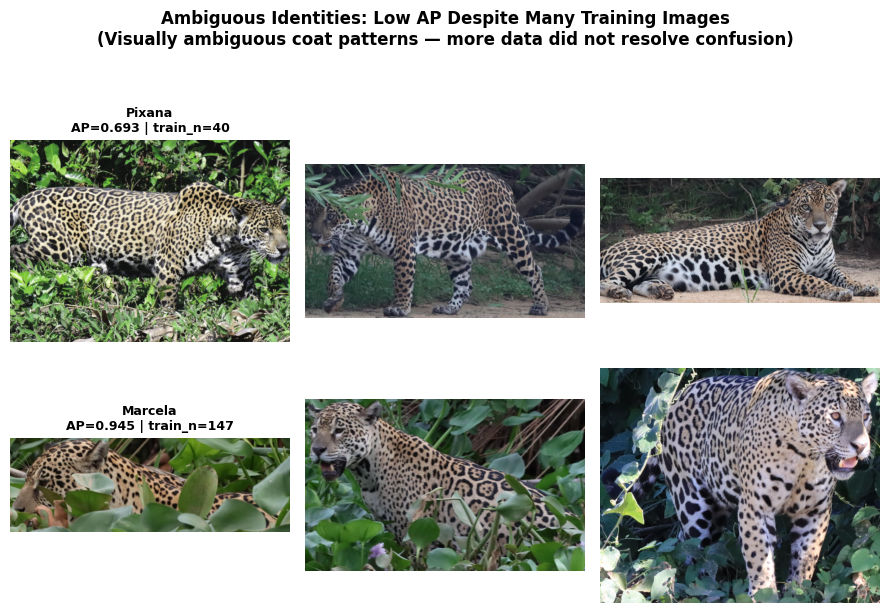

In [16]:
# Build identity → val image paths map
id_to_val_paths = defaultdict(list)
for path, label in zip(val_image_paths, val_labels):
    id_to_val_paths[label].append(path)

def show_identity_gallery(identities_df, group_title, n_images=3):
    n_ids = len(identities_df)
    fig, axes = plt.subplots(n_ids, n_images, figsize=(n_images * 3, n_ids * 3.2))
    if n_ids == 1:
        axes = axes[np.newaxis, :]

    for row_idx, (_, row) in enumerate(identities_df.iterrows()):
        identity   = row["identity"]
        ap_val     = row["ap"]
        tr_count   = row["train_count"]
        img_paths  = id_to_val_paths[identity][:n_images]

        for col_idx in range(n_images):
            ax = axes[row_idx, col_idx]
            if col_idx < len(img_paths):
                try:
                    img = Image.open(img_paths[col_idx]).convert("RGB")
                    ax.imshow(img)
                except Exception:
                    ax.text(0.5, 0.5, "N/A", ha="center", va="center",
                            transform=ax.transAxes)
            else:
                ax.axis("off")
                continue
            ax.axis("off")
            if col_idx == 0:
                ax.set_title(f"{identity}\nAP={ap_val:.3f} | train_n={tr_count}",
                             fontsize=9, fontweight="bold")

    plt.suptitle(group_title, fontsize=12, fontweight="bold", y=1.01)
    plt.tight_layout()
    return fig

# Show top-2 from Efficient and Ambiguous quadrants
top2_efficient = efficient.head(2)
top2_ambiguous = ambiguous.head(2)

fig_eff = show_identity_gallery(
    top2_efficient,
    "Efficient Identities: High AP Despite Few Training Images\n"
    "(Visually distinctive coat patterns — model generalises from few examples)"
)
wandb.log({"per_identity/efficient_gallery": wandb.Image(fig_eff)})
plt.savefig(config["checkpoint_dir"] / "exp15_efficient_gallery.png", dpi=120, bbox_inches="tight")
plt.show()

fig_amb = show_identity_gallery(
    top2_ambiguous,
    "Ambiguous Identities: Low AP Despite Many Training Images\n"
    "(Visually ambiguous coat patterns — more data did not resolve confusion)"
)
wandb.log({"per_identity/ambiguous_gallery": wandb.Image(fig_amb)})
plt.savefig(config["checkpoint_dir"] / "exp15_ambiguous_gallery.png", dpi=120, bbox_inches="tight")
plt.show()


## 15. Full Results Table and Summary

In [17]:
print("=" * 72)
print("EXPERIMENT 15: CLASS IMBALANCE VS PER-IDENTITY AP — RESULTS SUMMARY")
print("=" * 72)
print()
print(f"  Model:         DINOv2-ViT-L/14 + ArcFace (Exp13 best config)")
print(f"  Best val mAP:  {best_map:.4f}  (epoch {best_epoch})")
print()
print(f"  Spearman ρ:    {rho:+.4f}  (p={pval:.4f})")
sig_str = f"Significant at p<0.05" if pval < 0.05 else "NOT significant at p<0.05"
print(f"  Significance:  {sig_str}")
print()
print(f"  Median training count: {median_count:.0f}")
print(f"  Median AP:             {median_ap:.4f}")
print()
print(f"  Quadrant summary:")
for q, c in quadrant_colors.items():
    n = int((analysis_df["quadrant"] == q).sum())
    print(f"    {q:<45} n={n}")
print()
print("  Full per-identity table (sorted by AP descending):")
print(f"  {'Identity':<20} {'AP':>6}  {'Train N':>7}  {'Val N':>5}  Quadrant")
print("  " + "-" * 65)
for _, row in analysis_df.sort_values("ap", ascending=False).iterrows():
    quad_short = row["quadrant"].split("(")[0].strip()
    print(f"  {row['identity']:<20} {row['ap']:.4f}  {row['train_count']:>7}  "
          f"{row['val_count']:>5}  {quad_short}")
print("=" * 72)

# Log full table to W&B
wandb.log({"per_identity/full_table": wandb.Table(dataframe=analysis_df)})


EXPERIMENT 15: CLASS IMBALANCE VS PER-IDENTITY AP — RESULTS SUMMARY

  Model:         DINOv2-ViT-L/14 + ArcFace (Exp13 best config)
  Best val mAP:  0.8676  (epoch 27)

  Spearman ρ:    +0.2828  (p=0.1232)
  Significance:  NOT significant at p<0.05

  Median training count: 36
  Median AP:             0.9926

  Quadrant summary:
    Efficient (low data, high AP)                 n=6
    Data-hungry (high data, high AP)              n=10
    Ambiguous (high data, low AP)                 n=5
    Difficult (low data, low AP)                  n=10

  Full per-identity table (sorted by AP descending):
  Identity                 AP  Train N  Val N  Quadrant
  -----------------------------------------------------------------
  Abril                1.0000       17      4  Efficient
  Akaloi               1.0000       15      4  Efficient
  Alira                1.0000       18      5  Efficient
  Jaju                 1.0000       83     21  Data-hungry
  Kamaikua             1.0000       84     

## 16. Finish

In [18]:
wandb.finish()
print("W&B run completed ✓")
print()
print("Key outputs saved:")
print(f"  Checkpoint:            exp15_dinov2_arcface_best.pth")
print(f"  Training curves plot:  exp15_training_curves.png")
print(f"  Correlation plot:      exp15_correlation.png")
print(f"  Efficient gallery:     exp15_efficient_gallery.png")
print(f"  Ambiguous gallery:     exp15_ambiguous_gallery.png")


correlation/median_ap,▁
correlation/median_train_count,▁
correlation/n_ambiguous,▁
correlation/n_data_hungry,▁
correlation/n_difficult,▁
correlation/n_efficient,▁
correlation/n_identities,▁
correlation/p_value,▁
correlation/spearman_rho,▁
num_identities,▁
+9,...


W&B run completed ✓

Key outputs saved:
  Checkpoint:            exp15_dinov2_arcface_best.pth
  Training curves plot:  exp15_training_curves.png
  Correlation plot:      exp15_correlation.png
  Efficient gallery:     exp15_efficient_gallery.png
  Ambiguous gallery:     exp15_ambiguous_gallery.png
